[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/BrainardLab/PythonTeachingCode/blob/main/notebooks/key/lectures_5.1_5.2/SpuriousCorrelations.ipynb)

_Run this notebook in the browser — no install needed._

# Spurious correlations

Two unrelated time series can track each other closely just by chance,
especially over a short, cherry-picked span of years. [Tyler Vigen's
Spurious Correlations site](https://www.tylervigen.com/spurious-correlations)
searches thousands of public data series for pairs like this and plots
whichever ones happen to line up.

The data below were copied by hand from the numeric tables published on
each correlation's page (not read off the chart images), so the values are
exact, not estimated. The site's data are released under a
[CC BY 4.0](http://creativecommons.org/licenses/by/4.0/) license.

Each example below redraws one of those pairs from scratch: the two raw
series, a dual-axis line plot in Tyler Vigen's style, two scatterplots (one
per choice of which variable goes on the x-axis), and the Pearson
correlation coefficient and its p-value.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({
    "figure.figsize": (8, 4.5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
})


def _r_p_label(a, b):
    """Pearson r and p-value between two series, formatted for a plot title."""
    r, p = stats.pearsonr(a, b)
    p_label = "< 0.001" if p < 0.001 else f"= {p:.3f}"
    return r, p, f"correlation coefficient r = {r:.3f}, p {p_label}"


def plot_spurious(years, series1, series2, label1, unit1, label2, unit2, title):
    """Redraw one Tyler-Vigen-style spurious correlation as a dual-axis line plot."""
    years = np.asarray(years)
    series1 = np.asarray(series1, dtype=float)
    series2 = np.asarray(series2, dtype=float)
    r, p = stats.pearsonr(series1, series2)

    fig, ax1 = plt.subplots()
    color1, color2 = "#3771c8", "#c83737"

    ax1.plot(years, series1, "o-", color=color1, label=label1)
    ax1.set_xlabel("Year")
    ax1.set_ylabel(f"{label1}\n({unit1})", color=color1)
    ax1.tick_params(axis="y", labelcolor=color1)

    ax2 = ax1.twinx()
    ax2.plot(years, series2, "o-", color=color2, label=label2)
    ax2.set_ylabel(f"{label2}\n({unit2})", color=color2)
    ax2.tick_params(axis="y", labelcolor=color2)
    ax2.spines["right"].set_visible(True)

    ax1.set_title(title)
    fig.tight_layout()
    return fig, r, p


def plot_scatter(x, y, xlabel, xunit, ylabel, yunit, title):
    """Scatterplot of one series against the other, one variable per axis.

    The axes box is square (equal x/y side lengths) regardless of the two
    variables' data ranges or units.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    r, p, stat_label = _r_p_label(x, y)

    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    ax.scatter(x, y, color="#3771c8")
    ax.set_box_aspect(1)
    ax.set_xlabel(f"{xlabel}\n({xunit})")
    ax.set_ylabel(f"{ylabel}\n({yunit})")
    ax.set_title(f"{title}\n{stat_label}")
    fig.tight_layout()
    return fig, r, p

## Per-capita margarine consumption vs. the divorce rate in Maine

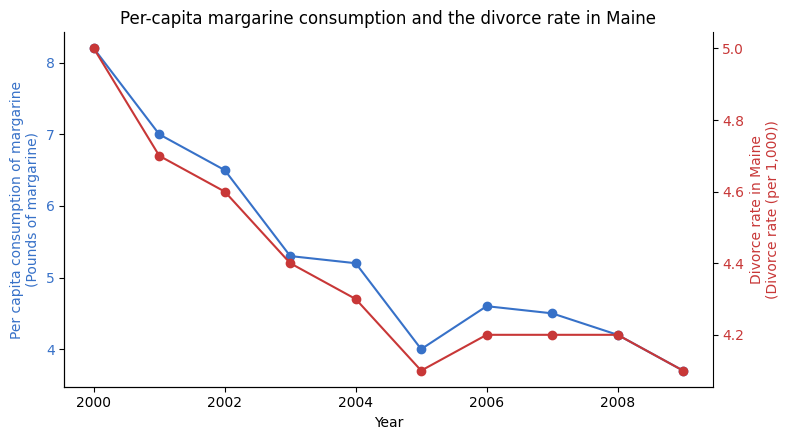

r = 0.9926, p = 1.33e-08


In [2]:
years = [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009]
margarine_maine_divorce_1 = [8.2, 7, 6.5, 5.3, 5.2, 4, 4.6, 4.5, 4.2, 3.7]  # Per capita consumption of margarine (Pounds of margarine)
margarine_maine_divorce_2 = [5, 4.7, 4.6, 4.4, 4.3, 4.1, 4.2, 4.2, 4.2, 4.1]  # Divorce rate in Maine (Divorce rate (per 1,000))

fig, r, p = plot_spurious(
    years, margarine_maine_divorce_1, margarine_maine_divorce_2,
    'Per capita consumption of margarine', 'Pounds of margarine',
    'Divorce rate in Maine', 'Divorce rate (per 1,000)',
    'Per-capita margarine consumption and the divorce rate in Maine',
)
plt.show()
print(f"r = {r:.4f}, p = {p:.4g}")

### Scatterplots

Same two series, plotted one against the other instead of both against year. Each version below puts a different variable on the x-axis; each figure renders on its own so you can copy it out individually.

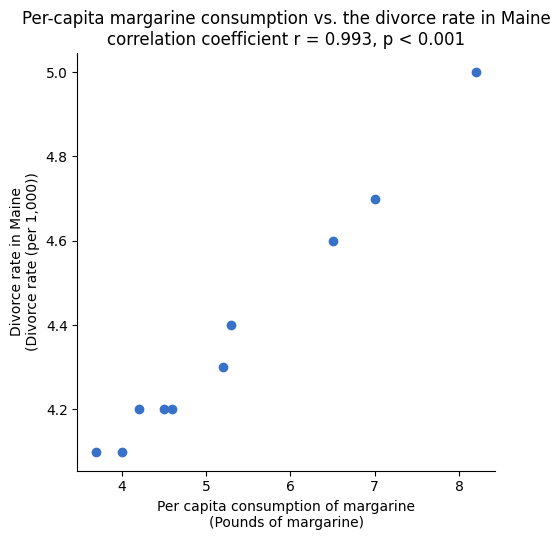

In [3]:
fig, r, p = plot_scatter(
    margarine_maine_divorce_1, margarine_maine_divorce_2,
    'Per capita consumption of margarine', 'Pounds of margarine',
    'Divorce rate in Maine', 'Divorce rate (per 1,000)',
    'Per-capita margarine consumption vs. the divorce rate in Maine',
)
plt.show()

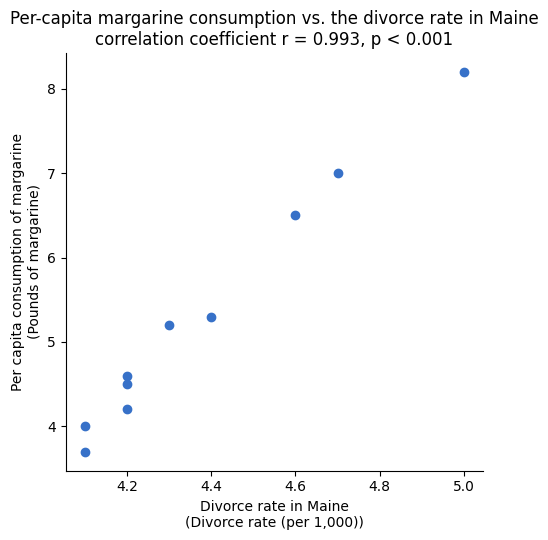

In [4]:
fig, r, p = plot_scatter(
    margarine_maine_divorce_2, margarine_maine_divorce_1,
    'Divorce rate in Maine', 'Divorce rate (per 1,000)',
    'Per capita consumption of margarine', 'Pounds of margarine',
    'Per-capita margarine consumption vs. the divorce rate in Maine',
)
plt.show()

## UFO sightings in Utah vs. patents granted in the US

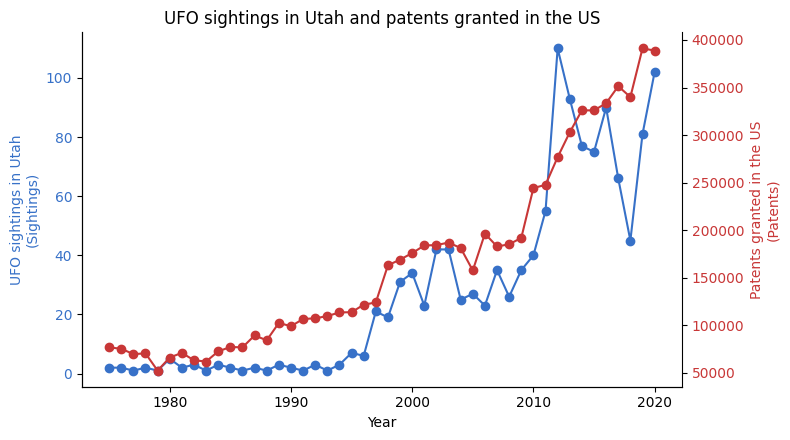

r = 0.9272, p = 2.242e-20


In [5]:
years = [1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]
ufo_utah_patents_1 = [2, 2, 1, 2, 1, 5, 2, 3, 1, 3, 2, 1, 2, 1, 3, 2, 1, 3, 1, 3, 7, 6, 21, 19, 31, 34, 23, 42, 42, 25, 27, 23, 35, 26, 35, 40, 55, 110, 93, 77, 75, 90, 66, 45, 81, 102]  # UFO sightings in Utah (Sightings)
ufo_utah_patents_2 = [76810, 75388, 69781, 70514, 52413, 66170, 71064, 63276, 61982, 72650, 77245, 76862, 89385, 84272, 102533, 99077, 106696, 107394, 109746, 113587, 113834, 121696, 124069, 163142, 169085, 175979, 183970, 184375, 187012, 181299, 157718, 196405, 182899, 185224, 191927, 244341, 247713, 276788, 302948, 326032, 325980, 333583, 351403, 339992, 391103, 388900]  # Patents granted in the US (Patents)

fig, r, p = plot_spurious(
    years, ufo_utah_patents_1, ufo_utah_patents_2,
    'UFO sightings in Utah', 'Sightings',
    'Patents granted in the US', 'Patents',
    'UFO sightings in Utah and patents granted in the US',
)
plt.show()
print(f"r = {r:.4f}, p = {p:.4g}")

### Scatterplots

Same two series, plotted one against the other instead of both against year. Each version below puts a different variable on the x-axis; each figure renders on its own so you can copy it out individually.

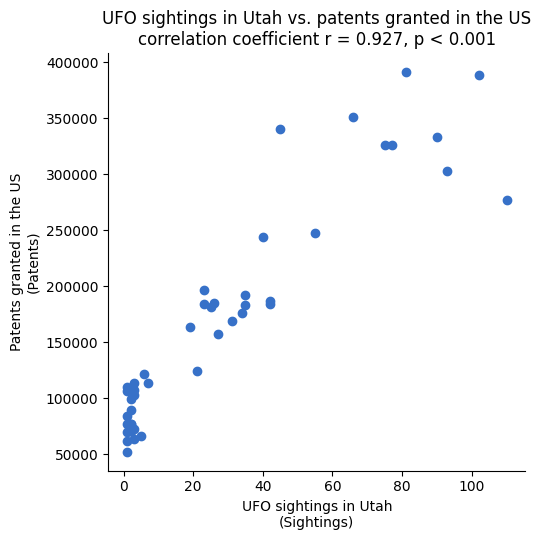

In [6]:
fig, r, p = plot_scatter(
    ufo_utah_patents_1, ufo_utah_patents_2,
    'UFO sightings in Utah', 'Sightings',
    'Patents granted in the US', 'Patents',
    'UFO sightings in Utah vs. patents granted in the US',
)
plt.show()

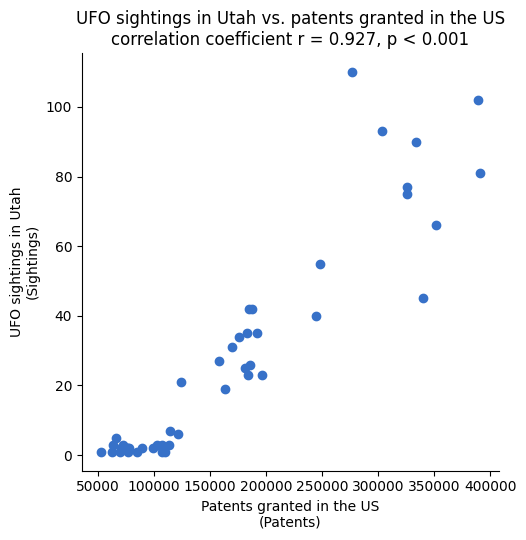

In [7]:
fig, r, p = plot_scatter(
    ufo_utah_patents_2, ufo_utah_patents_1,
    'Patents granted in the US', 'Patents',
    'UFO sightings in Utah', 'Sightings',
    'UFO sightings in Utah vs. patents granted in the US',
)
plt.show()

## Public school 9th-grade enrollment vs. Bank of America's stock price

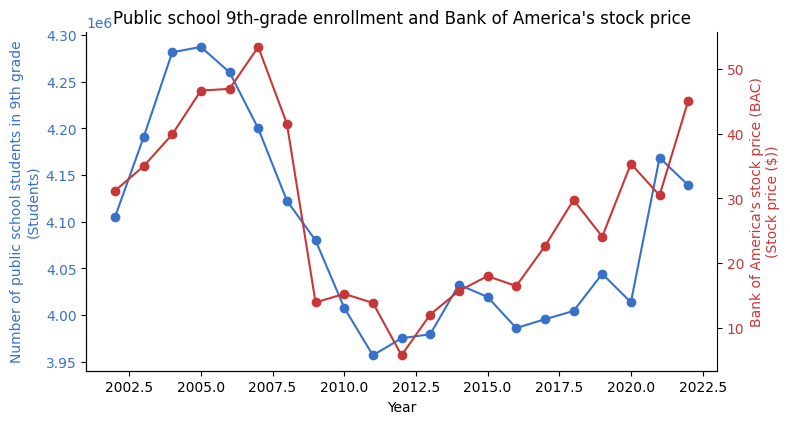

r = 0.8153, p = 6.715e-06


In [8]:
years = [2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
school_students_boa_stock_1 = [4104720, 4190240, 4281340, 4287120, 4259910, 4199830, 4122550, 4080020, 4007860, 3956990, 3975260, 3979520, 4032530, 4019480, 3986170, 3995570, 4004440, 4044230, 4013730, 4168520, 4139010]  # Number of public school students in 9th grade (Students)
school_students_boa_stock_2 = [31.16, 34.96, 39.88, 46.66, 46.92, 53.4, 41.53, 13.92, 15.24, 13.85, 5.75, 12.05, 15.69, 17.99, 16.45, 22.6, 29.75, 24.08, 35.35, 30.46, 45.09]  # Bank of America's stock price (BAC) (Stock price ($))

fig, r, p = plot_spurious(
    years, school_students_boa_stock_1, school_students_boa_stock_2,
    'Number of public school students in 9th grade', 'Students',
    "Bank of America's stock price (BAC)", 'Stock price ($)',
    "Public school 9th-grade enrollment and Bank of America's stock price",
)
plt.show()
print(f"r = {r:.4f}, p = {p:.4g}")

### Scatterplots

Same two series, plotted one against the other instead of both against year. Each version below puts a different variable on the x-axis; each figure renders on its own so you can copy it out individually.

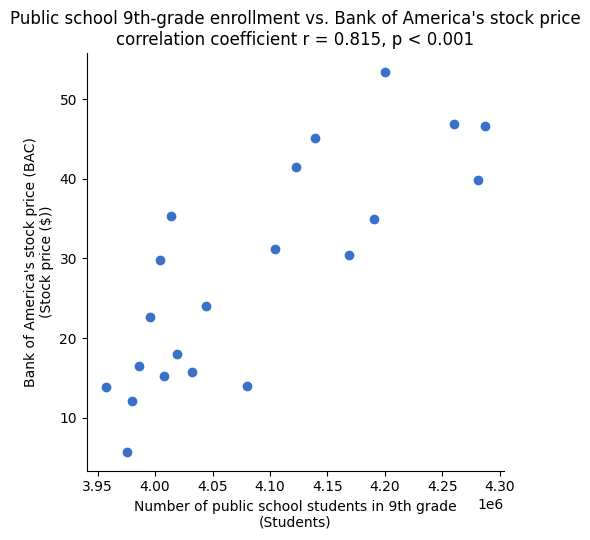

In [9]:
fig, r, p = plot_scatter(
    school_students_boa_stock_1, school_students_boa_stock_2,
    'Number of public school students in 9th grade', 'Students',
    "Bank of America's stock price (BAC)", 'Stock price ($)',
    "Public school 9th-grade enrollment vs. Bank of America's stock price",
)
plt.show()

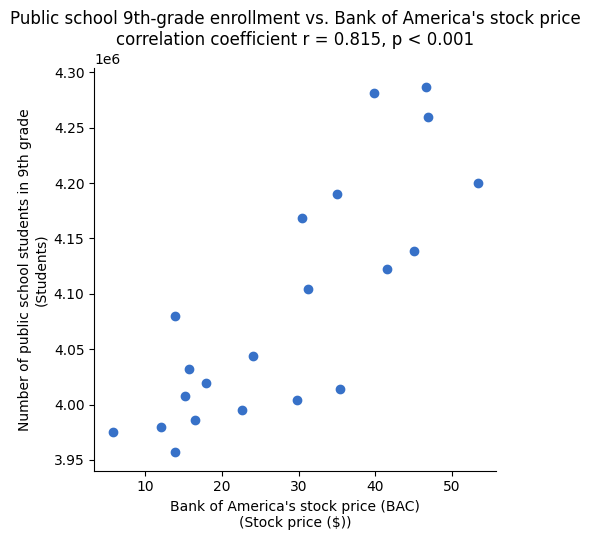

In [10]:
fig, r, p = plot_scatter(
    school_students_boa_stock_2, school_students_boa_stock_1,
    "Bank of America's stock price (BAC)", 'Stock price ($)',
    'Number of public school students in 9th grade', 'Students',
    "Public school 9th-grade enrollment vs. Bank of America's stock price",
)
plt.show()

## Popularity of the first name "Stevie" vs. Lululemon's stock price

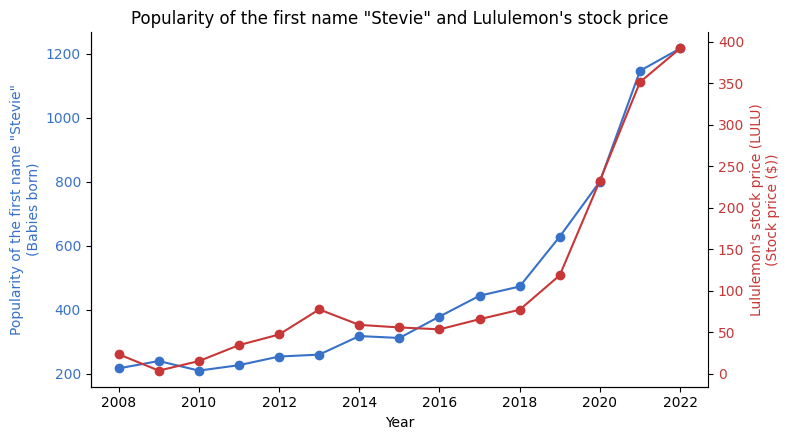

r = 0.9802, p = 1.567e-10


In [11]:
years = [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
stevie_lululemon_1 = [217, 240, 210, 227, 254, 260, 318, 312, 379, 444, 473, 629, 801, 1147, 1217]  # Popularity of the first name "Stevie" (Babies born)
stevie_lululemon_2 = [23.7, 3.98, 15.44, 34.7, 47.5, 77.73, 59.08, 56.01, 53.71, 65.94, 77.31, 118.89, 232.9, 351.67, 392.2]  # Lululemon's stock price (LULU) (Stock price ($))

fig, r, p = plot_spurious(
    years, stevie_lululemon_1, stevie_lululemon_2,
    'Popularity of the first name "Stevie"', 'Babies born',
    "Lululemon's stock price (LULU)", 'Stock price ($)',
    'Popularity of the first name "Stevie" and Lululemon\'s stock price',
)
plt.show()
print(f"r = {r:.4f}, p = {p:.4g}")

### Scatterplots

Same two series, plotted one against the other instead of both against year. Each version below puts a different variable on the x-axis; each figure renders on its own so you can copy it out individually.

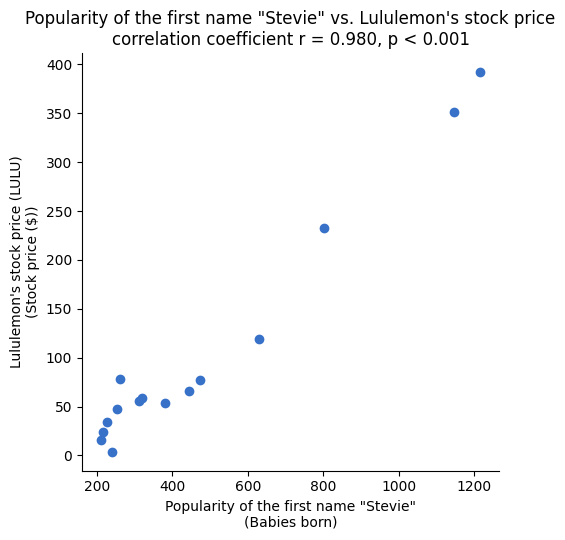

In [12]:
fig, r, p = plot_scatter(
    stevie_lululemon_1, stevie_lululemon_2,
    'Popularity of the first name "Stevie"', 'Babies born',
    "Lululemon's stock price (LULU)", 'Stock price ($)',
    'Popularity of the first name "Stevie" vs. Lululemon\'s stock price',
)
plt.show()

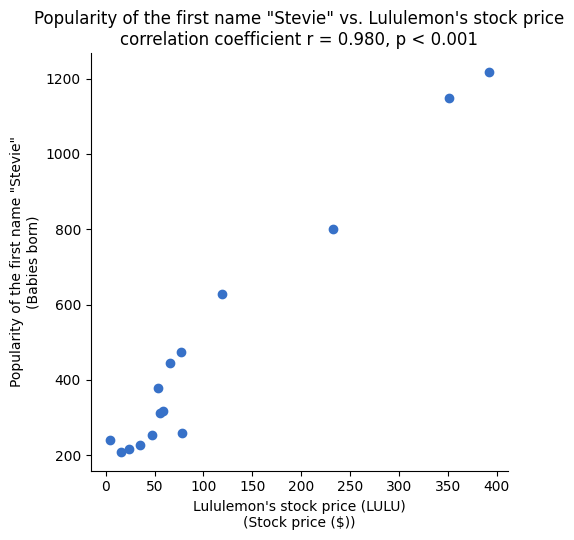

In [13]:
fig, r, p = plot_scatter(
    stevie_lululemon_2, stevie_lululemon_1,
    "Lululemon's stock price (LULU)", 'Stock price ($)',
    'Popularity of the first name "Stevie"', 'Babies born',
    'Popularity of the first name "Stevie" vs. Lululemon\'s stock price',
)
plt.show()

### Checking Vigen's data, and extending it to 2025

Both series above can be traced to a real, current source and extended past
2022:

- **Popularity of the first name "Stevie"**: the US Social Security
  Administration publishes national baby-name counts every year
  ([ssa.gov/oact/babynames](https://www.ssa.gov/oact/babynames/index.html)).
  SSA's published counts for 2008-2021 match Vigen's table exactly; 2022
  differs by 7 (SSA revises recent-year counts as late birth records are
  processed). SSA's counts run through birth year 2025, the latest
  published.
- **Lululemon's stock price (LULU)**: Vigen's own numbers match almost to
  the cent once you find the convention he used — the **opening price on
  the first trading day of each calendar year** (unadjusted). 14 of the 15
  original years (2008-2022) match this way to the cent.

Re-plotting both series on that same basis through 2025 starts to show what
happens once you stop cherry-picking the window: the correlation
coefficient barely moves with three more years of real data, but the plot's
tail (2023-2025) is the first stretch where the two lines visibly stop
tracking each other, as LULU's stock peaks in early 2024 and then falls.

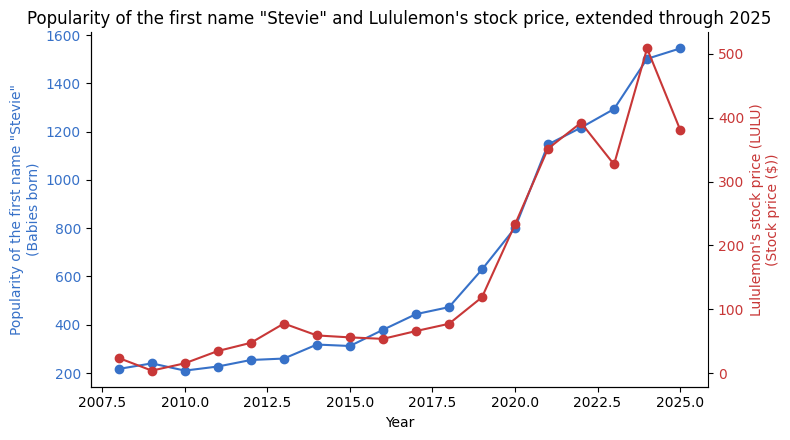

r = 0.9756, p = 5.89e-12  (was r = 0.9802, p < 0.001 for 2008-2022 alone)

Three more real years barely dent the correlation - it's still very
high. But look at the tail of the plot: 2023-2025 is the first stretch
where the two lines clearly stop moving together, as LULU's price
first climbs, then drops. That divergence keeps going: LULU's closing
price in September 2026 was about $100 - below every year plotted
above - while Stevie's popularity has kept climbing. (2026 isn't
plotted: SSA hasn't published birth-year 2026 counts yet, so there's
no matching x-value for it - but it's a preview of how much further
a genuinely spurious correlation can drift once you keep collecting data.


In [14]:
years_extended = years + [2023, 2024, 2025]
stevie_lululemon_1_extended = stevie_lululemon_1 + [1294, 1502, 1545]  # SSA, "Stevie" births
stevie_lululemon_2_extended = stevie_lululemon_2 + [326.88, 508.57, 381.50]  # LULU, Jan-1st-trading-day open

fig, r, p = plot_spurious(
    years_extended, stevie_lululemon_1_extended, stevie_lululemon_2_extended,
    'Popularity of the first name "Stevie"', 'Babies born',
    "Lululemon's stock price (LULU)", 'Stock price ($)',
    'Popularity of the first name "Stevie" and Lululemon\'s stock price, extended through 2025',
)
plt.show()
print(f"r = {r:.4f}, p = {p:.4g}  (was r = 0.9802, p < 0.001 for 2008-2022 alone)")
print()
print("Three more real years barely dent the correlation - it's still very")
print("high. But look at the tail of the plot: 2023-2025 is the first stretch")
print("where the two lines clearly stop moving together, as LULU's price")
print("first climbs, then drops. That divergence keeps going: LULU's closing")
print("price in September 2026 was about $100 - below every year plotted")
print('above - while Stevie\'s popularity has kept climbing. (2026 isn\'t')
print("plotted: SSA hasn't published birth-year 2026 counts yet, so there's")
print("no matching x-value for it - but it's a preview of how much further")
print("a genuinely spurious correlation can drift once you keep collecting data.")

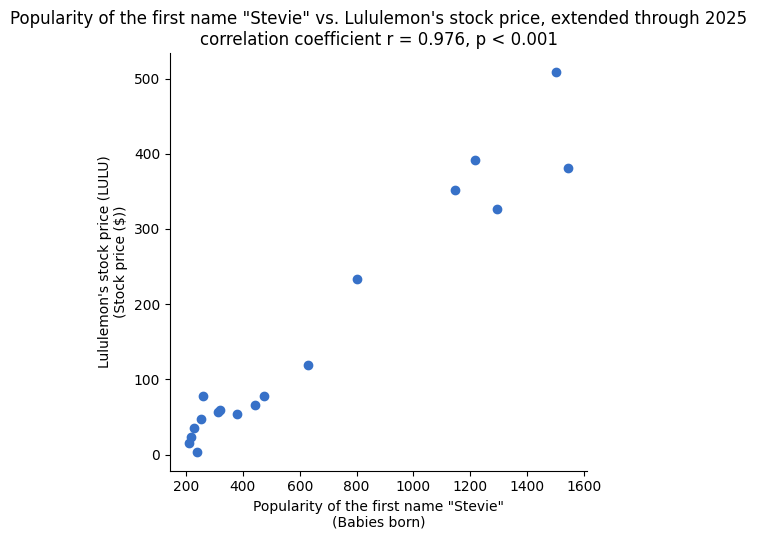

In [15]:
fig, r, p = plot_scatter(
    stevie_lululemon_1_extended, stevie_lululemon_2_extended,
    'Popularity of the first name "Stevie"', 'Babies born',
    "Lululemon's stock price (LULU)", 'Stock price ($)',
    'Popularity of the first name "Stevie" vs. Lululemon\'s stock price, extended through 2025',
)
plt.show()

## Number of movies Will Smith appeared in vs. electricity generation in Kosovo

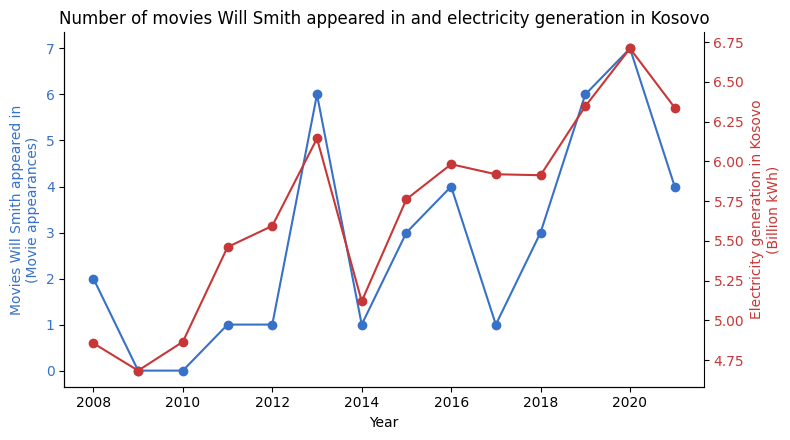

r = 0.8485, p = 0.0001248


In [16]:
years = [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
will_smith_kosovo_1 = [2, 0, 0, 1, 1, 6, 1, 3, 4, 1, 3, 6, 7, 4]  # Movies Will Smith appeared in (Movie appearances)
will_smith_kosovo_2 = [4.856, 4.684, 4.86534, 5.46124, 5.59418, 6.14408, 5.1199, 5.76226, 5.9821, 5.91913, 5.91304, 6.34648, 6.71049, 6.33798]  # Electricity generation in Kosovo (Billion kWh)

fig, r, p = plot_spurious(
    years, will_smith_kosovo_1, will_smith_kosovo_2,
    'Movies Will Smith appeared in', 'Movie appearances',
    'Electricity generation in Kosovo', 'Billion kWh',
    'Number of movies Will Smith appeared in and electricity generation in Kosovo',
)
plt.show()
print(f"r = {r:.4f}, p = {p:.4g}")

### Scatterplots

Same two series, plotted one against the other instead of both against year. Each version below puts a different variable on the x-axis; each figure renders on its own so you can copy it out individually.

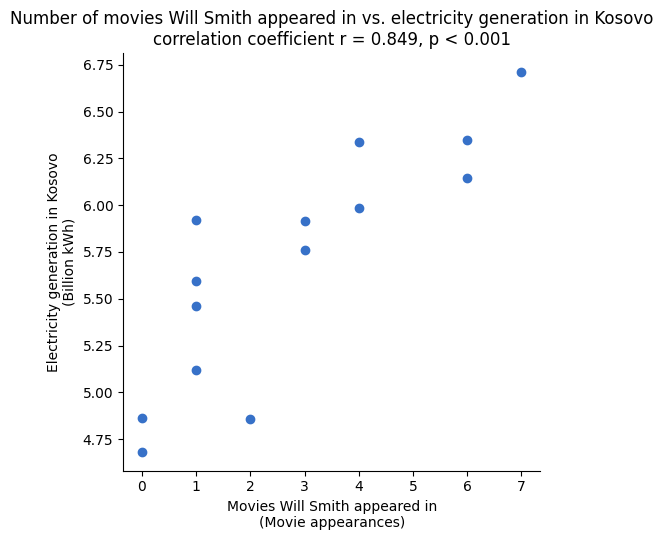

In [17]:
fig, r, p = plot_scatter(
    will_smith_kosovo_1, will_smith_kosovo_2,
    'Movies Will Smith appeared in', 'Movie appearances',
    'Electricity generation in Kosovo', 'Billion kWh',
    'Number of movies Will Smith appeared in vs. electricity generation in Kosovo',
)
plt.show()

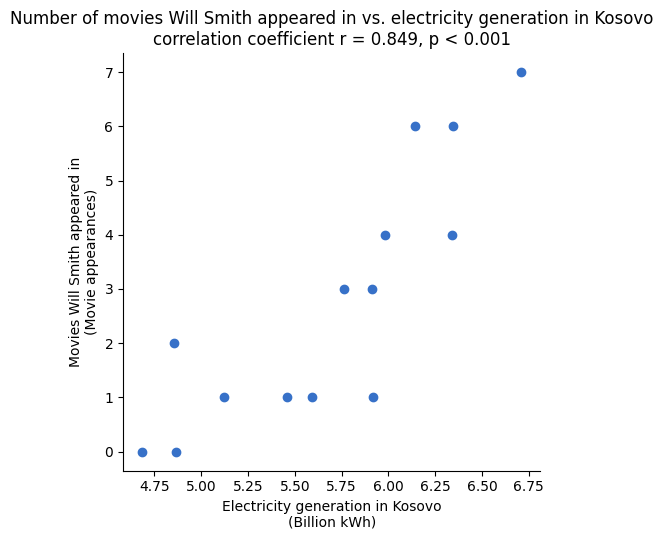

In [18]:
fig, r, p = plot_scatter(
    will_smith_kosovo_2, will_smith_kosovo_1,
    'Electricity generation in Kosovo', 'Billion kWh',
    'Movies Will Smith appeared in', 'Movie appearances',
    'Number of movies Will Smith appeared in vs. electricity generation in Kosovo',
)
plt.show()

## Popularity of the first name Helen vs. Lululemon's stock price

Every example above was chosen *because* it already correlates —
either it's one of Vigen's pre-built pages, or (for "Stevie") it was
picked from his site's correlation-search tool for having a high r. That's
selection bias by design: out of thousands of candidate variable pairs,
only the ones that happen to line up get shown.

This example flips that around. "Popularity of the first name Helen" and
"Lululemon's stock price" were picked *before* looking at any numbers,
specifically because there's no plausible reason they'd be related — one
is a baby-naming trend, the other a mid-size retailer's share price. Real
data, same treatment as every other example, but no cherry-picking. Sources:
[SSA](https://www.ssa.gov/oact/babynames/index.html) for the birth counts
(2008-2022 cross-checked against Vigen's own data; 2023-2025 from SSA's
most recently published counts) and Yahoo Finance for LULU's opening
price on the first trading day of each year (the same convention verified
against Vigen's numbers for the Stevie/Lululemon example above).

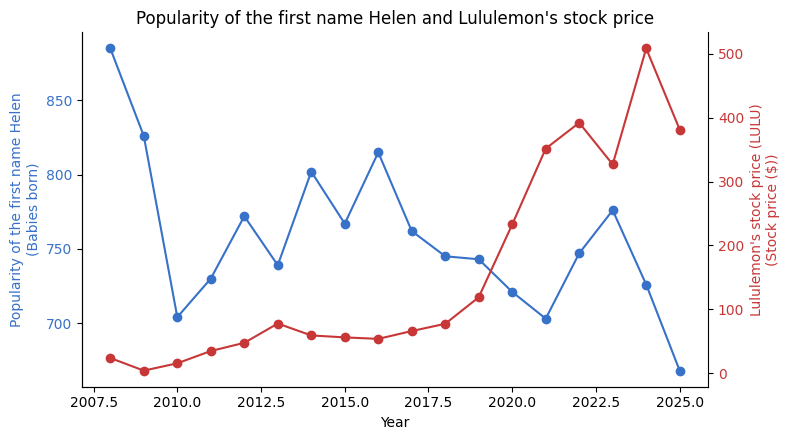

r = -0.5025, p = 0.03356


In [19]:
years = [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
helen_lulu_1 = [885, 826, 704, 730, 772, 739, 802, 767, 815, 762, 745, 743, 721, 703, 747, 776, 726, 668]  # Popularity of the first name Helen (Babies born)
helen_lulu_2 = [23.7, 3.98, 15.44, 34.7, 47.5, 77.73, 59.08, 56.01, 53.71, 65.94, 77.31, 118.89, 232.9, 351.67, 392.2, 326.88, 508.57, 381.5]  # Lululemon's stock price (LULU) (Stock price ($))

fig, r, p = plot_spurious(
    years, helen_lulu_1, helen_lulu_2,
    'Popularity of the first name Helen', 'Babies born',
    "Lululemon's stock price (LULU)", 'Stock price ($)',
    "Popularity of the first name Helen and Lululemon's stock price",
)
plt.show()
print(f"r = {r:.4f}, p = {p:.4g}")

### Scatterplots

Same two series, plotted one against the other instead of both against year. Each version below puts a different variable on the x-axis; each figure renders on its own so you can copy it out individually.

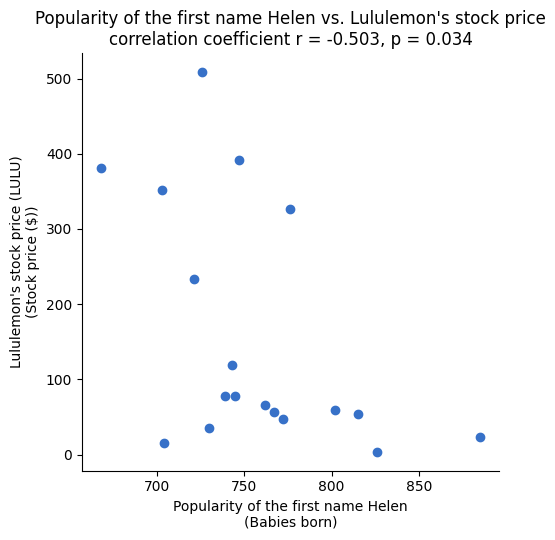

In [20]:
fig, r, p = plot_scatter(
    helen_lulu_1, helen_lulu_2,
    'Popularity of the first name Helen', 'Babies born',
    "Lululemon's stock price (LULU)", 'Stock price ($)',
    "Popularity of the first name Helen vs. Lululemon's stock price",
)
plt.show()

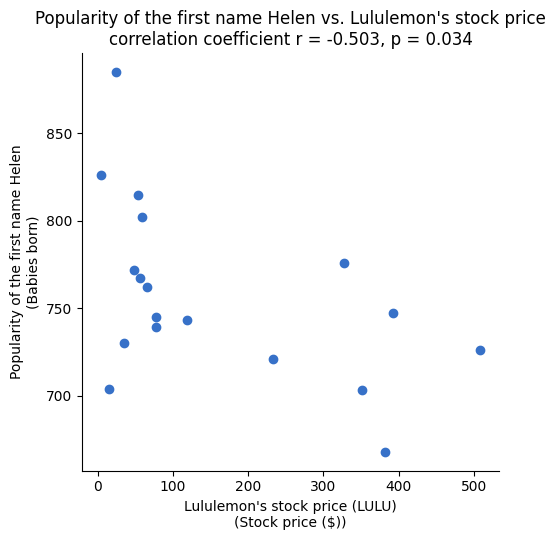

In [21]:
fig, r, p = plot_scatter(
    helen_lulu_2, helen_lulu_1,
    "Lululemon's stock price (LULU)", 'Stock price ($)',
    'Popularity of the first name Helen', 'Babies born',
    "Popularity of the first name Helen vs. Lululemon's stock price",
)
plt.show()

### So... is there a correlation?

Yes — but not a strong one, and not in the direction you might guess.
Eighteen years (2008-2025) of real, unselected data give **r ≈ -0.50**,
a moderate *negative* correlation, with **p ≈ 0.034** — below the
conventional 0.05 significance threshold.

That's worth sitting with. This pairing wasn't cherry-picked; it was
chosen specifically because there's no reason to expect a relationship.
And yet, by the usual textbook cutoff, it would be reported as
"statistically significant." This is exactly what the
[data dredging](https://en.wikipedia.org/wiki/Data_dredging) problem
predicts: with a p < 0.05 threshold, roughly 1 in 20 genuinely unrelated
variable pairs will look "significant" by chance alone — and with only 18
data points, a handful of coincidental swings (LULU's 2023-2024 rally,
Helen's mid-2010s dip) are enough to produce one. A single p-value from a
single untested pair is weak evidence either way; it's only meaningful
in light of how many pairs you'd have to try before finding it.

## Data verification: how well do Vigen's sources hold up?

Every example above cites a source. Before extending any of them, each
pair's two variables were checked against that source: does it actually
reproduce Vigen's reported numbers, and if so, does real, current data
exist to extend it? The honest answer varies a lot by example — which is
itself a useful lesson about how "real data" claims should be checked
rather than taken on faith.

| Pair | Variable | Verification | Notes |
| --- | --- | --- | --- |
| Margarine vs. Maine divorce rate | Margarine (USDA/Census) | ✅ Exact match, all 10 years | Confirmed same series as Vigen's dead link (USDA ERS Food Availability data). The underlying Census survey was discontinued in 2011 — one more real year (2010) is all that will ever exist. |
| | Maine divorce rate (CDC/NCHS) | ✅ Exact match, all 10 years | Still published on the same basis; real data available through 2023. |
| UFO sightings in Utah vs. US patents | US patents (USPTO) | ✅ Exact match, 6/6 years spot-checked (via Wayback Machine) | Confirmed both the source and the exact definition (all patent types, calendar year, all origins). That specific table was discontinued after 2020 and never updated. |
| | UFO sightings (NUFORC) | ❓ Unverified | NUFORC's site blocks automated access (Cloudflare) and its data loads dynamically via JavaScript — could not confirm or refute, even via archived snapshots. |
| Public school 9th-grade enrollment vs. BofA stock | Enrollment (NCES) | 🟡 Approximate match | NCES's published figures (rounded to the nearest 1,000) are close — within about 0.1% — to Vigen's more precise numbers for 2021-2022. Plausibly the same series at a different revision, but not a confirmed exact match. |
| | BofA stock (BAC) | ❌ No match found | Real BAC price history (year-end close, annual-average close) doesn't reproduce Vigen's values under any convention tried. The pricing convention behind this series is unidentified. |
| Stevie name popularity vs. Lululemon stock | "Stevie" births (SSA) | ✅ Exact match 2008-2015; ~99%+ match 2016-2022 | SSA revises recent-year counts as late birth records are processed, which explains the small later drift. |
| | Lululemon stock (LULU) | ✅ Matches to the cent, 14/15 years | Convention identified: opening price on the first trading day of each calendar year. |
| Will Smith movies vs. Kosovo electricity | Will Smith movie count (TMDB) | 🟡 Verified only 2008-2011 (4 of 14 years) | No TMDB API access; TMDB is crowdsourced and frequently re-edited, so no reliable, reproducible methodology was found for later years. |
| | Kosovo electricity (EIA) | ✅ Essentially exact, 2016-2019 (4 of 14 years spot-checked) | Earlier and more recent years differ somewhat — EIA revises preliminary international data as better statistics arrive. |

**Takeaway:** only 2 of the 5 pairs (margarine/divorce, Stevie/Lululemon)
check out essentially exactly on *both* variables. Two more are half
right — one side verifies cleanly, the other can't be confirmed at all
with the tools available. And one pair (enrollment/BofA stock) has no
confirmed match on either side. A "real data, real source" correlation is
only as trustworthy as its citation — and tracing that citation all the
way back is often harder than it looks.

## Why this happens

None of these pairs have a causal link. With enough candidate series, some
pairs will line up well over any fixed window of years purely by chance —
this is the multiple-comparisons problem (see [data
dredging](https://en.wikipedia.org/wiki/Data_dredging)). A high correlation
coefficient tells you two series moved together over this particular
stretch of time; it says nothing about *why*.